This notebook compares the trained CNN models against GPT-4o

 Install dependencies

In [34]:
%pip install python-dotenv openai pillow nltk bert_score tqdm pandas

Config & load data

In [20]:
import os
import pandas as pd
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

if not GITHUB_TOKEN:
    raise ValueError('GitHub token not set. Add it in Colab Secrets (🔑 icon in left sidebar).')
print('GitHub token loaded ✅')

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_DIR   = '/content/drive/MyDrive/ITAITA_Project'
MODEL_RESULTS = os.path.join(PROJECT_DIR, 'Model_Results')
os.makedirs(MODEL_RESULTS, exist_ok=True)

MASTER_CSV = os.path.join(PROJECT_DIR, 'Data', 'master_data.csv')

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv(MASTER_CSV)

# ── Fix file paths (Colab "My Laptop" prefix → shortcut path) ─────────────────
OLD_PREFIX = '/content/drive/Othercomputers/My Laptop/Desktop/ITAITA_Project/Data'
NEW_PREFIX = os.path.join(PROJECT_DIR, 'Data')
df['file_path'] = df['file_path'].str.replace(OLD_PREFIX, NEW_PREFIX, regex=False)

# ── Only test split needed for comparison ─────────────────────────────────────
test_data = df[df['split'] == 'test'].reset_index(drop=True)
print(f'Total test samples: {len(test_data)}')
print(test_data['dataset'].value_counts())

# ── Sanity check one path ──────────────────────────────────────────────────────
sample_path = test_data['file_path'].iloc[0]
print(f'\nSample path: {sample_path}')
print(f'File exists: {os.path.exists(sample_path)}')
if not os.path.exists(sample_path):
    print('⚠️  File not found — check the folder structure inside ITAITA_Project.')

GitHub token loaded ✅
Total test samples: 2238
dataset
TicTacToe_Data    750
Numbers_Data      744
Shapes_Data       744
Name: count, dtype: int64

Sample path: /content/drive/MyDrive/ITAITA_Project/Data/Numbers_Data/test/images/sample_000177.png
File exists: True


In [11]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [21]:
SAMPLE_SIZE = 150  # 50 per dataset

if SAMPLE_SIZE is not None:
    per_dataset = SAMPLE_SIZE // 3
    test_sample = (
        test_data
        .groupby('dataset', group_keys=False)
        .apply(lambda x: x.sample(min(per_dataset, len(x)), random_state=42))
        .reset_index(drop=True)
    )
    print(f'Using balanced sample: {len(test_sample)} images ({per_dataset} per dataset)')
else:
    test_sample = test_data
    print(f'Using full test set: {len(test_sample)} images')

print(test_sample['dataset'].value_counts())

Using balanced sample: 150 images (50 per dataset)
dataset
Numbers_Data      50
Shapes_Data       50
TicTacToe_Data    50
Name: count, dtype: int64


/tmp/ipykernel_28865/3185745643.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(per_dataset, len(x)), random_state=42))


 GPT-4o predictions

In [26]:
import base64
import io
import time
import json
import shutil
import pandas as pd
from PIL import Image as PILImage
from openai import OpenAI
from tqdm import tqdm
from google.colab import userdata, files

# ── OpenAI direct client (no rate limit issues) ────────────────────────────────
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=OPENAI_API_KEY)

GPT_MODEL     = 'gpt-4o'
GPT_SAVE_PATH = '/tmp/gpt4o_predictions.csv'

PROMPT = (
    'Describe this image in one short sentence. '
    'The image shows either simple geometric shapes, handwritten numbers, '
    'or a tic-tac-toe board. '
    'Mention the objects present, their colours, sizes, and positions concisely.'
)

def encode_image_b64(path):
    img = PILImage.open(path).convert('RGB')
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    return base64.b64encode(buf.getvalue()).decode('utf-8')

def query_gpt4o(row, retries=3):
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=GPT_MODEL,
                messages=[{
                    'role': 'user',
                    'content': [
                        {
                            'type': 'image_url',
                            'image_url': {
                                'url': f'data:image/png;base64,{encode_image_b64(row["file_path"])}'
                            }
                        },
                        {'type': 'text', 'text': PROMPT}
                    ]
                }],
                max_tokens=256
            )
            return {
                'file_path':  row['file_path'],
                'dataset':    row['dataset'],
                'reference':  row['text'],
                'prediction': response.choices[0].message.content.strip(),
            }
        except Exception as e:
            print(f'\n  Error ({attempt+1}/{retries}): {e}')
            time.sleep(2 ** (attempt + 1))
    return {
        'file_path': row['file_path'], 'dataset': row['dataset'],
        'reference': row['text'], 'prediction': ''
    }

# ── Restore from your downloaded CSV ──────────────────────────────────────────
uploaded = files.upload()
for filename, content in uploaded.items():
    with open(GPT_SAVE_PATH, 'wb') as f:
        f.write(content)
    print(f'Restored: {filename}')

# ── Resume — only fetch missing predictions ────────────────────────────────────
existing_df = pd.read_csv(GPT_SAVE_PATH)
done_paths  = set(existing_df.dropna(subset=['prediction'])['file_path'].tolist())
prior       = existing_df.dropna(subset=['prediction']).to_dict('records')
remaining   = test_sample[~test_sample['file_path'].isin(done_paths)]
print(f'Valid predictions already: {len(prior)}')
print(f'Remaining to fetch: {len(remaining)}')

# ── Run ────────────────────────────────────────────────────────────────────────
results = []
start   = time.time()

for _, row in tqdm(remaining.iterrows(), total=len(remaining), desc='GPT-4o'):
    result = query_gpt4o(row)
    results.append(result)
    if len(results) % 20 == 0:
        pd.DataFrame(prior + results).to_csv(GPT_SAVE_PATH, index=False)
        print(f'  Checkpoint — {len(results)} done')
    time.sleep(1)  # small delay, OpenAI handles much higher rates

all_results = prior + results
pd.DataFrame(all_results).to_csv(GPT_SAVE_PATH, index=False)

print(f'\nDone ✅  {len(all_results)} predictions in {time.time()-start:.0f}s')

# Download to your computer
files.download(GPT_SAVE_PATH)
print('Downloaded ✅')

Saving gpt4o_predictions (2).csv to gpt4o_predictions (2).csv
Restored: gpt4o_predictions (2).csv
Valid predictions already: 150
Remaining to fetch: 0


GPT-4o: 0it [00:00, ?it/s]


Done ✅  150 predictions in 0s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✅


In [17]:
from google.colab import files
import pandas as pd

# Download directly to your computer
df = pd.read_csv('/tmp/gpt4o_predictions.csv')
df.to_csv('/tmp/gpt4o_predictions.csv', index=False)
files.download('/tmp/gpt4o_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
print(gpt_df['dataset'].unique())

['Numbers_Data' 'Shapes_Data' 'TicTacToe_Data']


Score predictions

In [2]:
%pip install -q bert_score transformers==4.36.0 torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.0 which is incompatible.


In [28]:
import nltk
import json
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn
from google.colab import files

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

smoothie = SmoothingFunction().method1

# ── Load uploaded predictions file ────────────────────────────────────────────
# Upload your gpt4o_predictions.csv when prompted
uploaded = files.upload()
import io
GPT_SAVE_PATH    = '/tmp/gpt4o_predictions.csv'
gpt_results_path = '/tmp/gpt4o_results.json'

# Save uploaded file to tmp
for filename, content in uploaded.items():
    with open(GPT_SAVE_PATH, 'wb') as f:
        f.write(content)
    print(f'Loaded: {filename}')

def exact_match(ref, hyp):
    return float(ref.strip() == hyp.strip())

def bleu4(ref, hyp):
    ref_tokens = ref.strip().split()
    hyp_tokens = hyp.strip().split()
    if not hyp_tokens:
        return 0.0
    return sentence_bleu([ref_tokens], hyp_tokens,
                         weights=(0.25, 0.25, 0.25, 0.25),
                         smoothing_function=smoothie)

def meteor(ref, hyp):
    ref_tokens = ref.strip().split()
    hyp_tokens = hyp.strip().split()
    if not hyp_tokens:
        return 0.0
    return meteor_score([ref_tokens], hyp_tokens)

def score_df(df):
    refs = df['reference'].fillna('').tolist()
    hyps = df['prediction'].fillna('').tolist()
    df   = df.copy()
    print('  Computing Exact Match, BLEU-4, METEOR...')
    df['exact_match'] = [exact_match(r, h) for r, h in zip(refs, hyps)]
    df['bleu4']       = [bleu4(r, h)       for r, h in zip(refs, hyps)]
    df['meteor']      = [meteor(r, h)      for r, h in zip(refs, hyps)]
    print('  Computing BERTScore (~1-2 min)...')
    _, _, F1 = bert_score_fn(hyps, refs, lang='en', verbose=False,
                              model_type='distilbert-base-uncased')
    df['bertscore'] = F1.tolist()
    return df

def aggregate(df):
    return {
        'Exact Match': round(df['exact_match'].mean(), 4),
        'BLEU-4':      round(df['bleu4'].mean(), 4),
        'METEOR':      round(df['meteor'].mean(), 4),
        'BERTScore':   round(df['bertscore'].mean(), 4),
        'n':           len(df),
    }

print('Scoring GPT-4o predictions...')
gpt_df = pd.read_csv(GPT_SAVE_PATH)
print(f'Loaded {len(gpt_df)} predictions')
gpt_df = score_df(gpt_df)

gpt_results = {'overall': aggregate(gpt_df)}
for ds in ['Shapes_Data', 'Numbers_Data', 'TicTacToe_Data']:
    sub = gpt_df[gpt_df['dataset'] == ds]
    if len(sub) > 0:
        gpt_results[ds] = aggregate(sub)

print('\nGPT-4o overall results:')
for metric, val in gpt_results['overall'].items():
    print(f'  {metric}: {val}')

# Save and download
gpt_df.to_csv(GPT_SAVE_PATH, index=False)
with open(gpt_results_path, 'w') as f:
    json.dump(gpt_results, f, indent=2)

print('\nDownloading files...')
files.download(GPT_SAVE_PATH)
files.download(gpt_results_path)
print('Done ✅')

Saving gpt4o_predictions (2).csv to gpt4o_predictions (2) (1).csv
Loaded: gpt4o_predictions (2) (1).csv
Scoring GPT-4o predictions...
Loaded 150 predictions
  Computing Exact Match, BLEU-4, METEOR...
  Computing BERTScore (~1-2 min)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



GPT-4o overall results:
  Exact Match: 0.0
  BLEU-4: 0.0243
  METEOR: 0.1404
  BERTScore: 0.7693
  n: 150



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done ✅


Combined comparison table

In [30]:
import os
from IPython.display import display

import os
import json
import pandas as pd

MODEL_RESULTS    = '/content/drive/MyDrive'
gpt_results_path = '/tmp/gpt4o_results.json'
GPT_SAVE_PATH    = '/tmp/gpt4o_predictions.csv'

cnn_results_path = '/content/drive/MyDrive/ITAITA_Project/Model_Results/evaluation_results.json'

if not os.path.exists(cnn_results_path):
    print(f'CNN results not found at: {cnn_results_path}')
    print('Run the evaluation cells in your main notebook first.')
    cnn_results = {}
else:
    with open(cnn_results_path) as f:
        cnn_results = json.load(f)
    print(f'CNN results loaded ✅  ({len(cnn_results)} models)')

with open(gpt_results_path) as f:
    gpt_results = json.load(f)

rows = []

CNN_MODELS = [
    'ShallowCNN_simple', 'ShallowCNN_bert',
    'DeepCNN_simple',    'DeepCNN_bert',
    'ResNetCNN_simple',  'ResNetCNN_bert',
]
for run in CNN_MODELS:
    if run not in cnn_results:
        continue
    d = cnn_results[run]['overall']
    rows.append({
        'Model':       run.replace('_', ' — ', 1),
        'Type':        'CNN (ours)',
        'Exact Match': d.get('exact_match', d.get('Exact Match', 0)),
        'BLEU-4':      d.get('bleu4',       d.get('BLEU-4', 0)),
        'METEOR':      d.get('meteor',       d.get('METEOR', 0)),
        'BERTScore':   d.get('bertscore',    d.get('BERTScore', 0)),
    })

d = gpt_results['overall']
rows.append({
    'Model':       f'GPT-4o (n={d["n"]})',
    'Type':        'Commercial LLM',
    'Exact Match': d['Exact Match'],
    'BLEU-4':      d['BLEU-4'],
    'METEOR':      d['METEOR'],
    'BERTScore':   d['BERTScore'],
})

df_compare = pd.DataFrame(rows).set_index('Model')

display(
    df_compare.style
      .format('{:.4f}', subset=['Exact Match', 'BLEU-4', 'METEOR', 'BERTScore'])
      .highlight_max(axis=0,
                     subset=['Exact Match', 'BLEU-4', 'METEOR', 'BERTScore'],
                     color='#d4edda')
      .highlight_min(axis=0,
                     subset=['Exact Match', 'BLEU-4', 'METEOR', 'BERTScore'],
                     color='#fde8e8')
      .set_caption('CNN models vs GPT-4o — image-to-sentence prediction')
      .set_table_styles([{
          'selector': 'caption',
          'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]
      }])
)

out_csv = os.path.join(MODEL_RESULTS, 'full_comparison_table.csv')
df_compare.to_csv(out_csv)
print(f'Comparison table saved → {out_csv}')

CNN results loaded ✅  (6 models)


,Type,Exact Match,BLEU-4,METEOR,BERTScore
Model,,,,,
ShallowCNN — simple,CNN (ours),0.0000,0.1398,0.4065,0.9086
ShallowCNN — bert,CNN (ours),0.0000,0.1542,0.4236,0.9216
DeepCNN — simple,CNN (ours),0.0000,0.1987,0.4807,0.9183
DeepCNN — bert,CNN (ours),0.0004,0.2190,0.4994,0.9292
ResNetCNN — simple,CNN (ours),0.0000,0.1895,0.4677,0.9172
ResNetCNN — bert,CNN (ours),0.0036,0.2371,0.5040,0.9299
GPT-4o (n=150),Commercial LLM,0.0000,0.0243,0.1404,0.7693


Comparison table saved → /content/drive/MyDrive/full_comparison_table.csv


Per-dataset breakdown

In [31]:
print('GPT-4o results per dataset:\n')
for ds in ['Shapes_Data', 'Numbers_Data', 'TicTacToe_Data']:
    if ds in gpt_results:
        d = gpt_results[ds]
        print(f'  {ds} (n={d["n"]}):')
        print(f'    Exact Match: {d["Exact Match"]}')
        print(f'    BLEU-4:      {d["BLEU-4"]}')
        print(f'    METEOR:      {d["METEOR"]}')
        print(f'    BERTScore:   {d["BERTScore"]}')
        print()

GPT-4o results per dataset:

  Shapes_Data (n=50):
    Exact Match: 0.0
    BLEU-4:      0.0542
    METEOR:      0.2799
    BERTScore:   0.857

  Numbers_Data (n=50):
    Exact Match: 0.0
    BLEU-4:      0.0119
    METEOR:      0.0945
    BERTScore:   0.747

  TicTacToe_Data (n=50):
    Exact Match: 0.0
    BLEU-4:      0.007
    METEOR:      0.0469
    BERTScore:   0.704



Qualitative examples

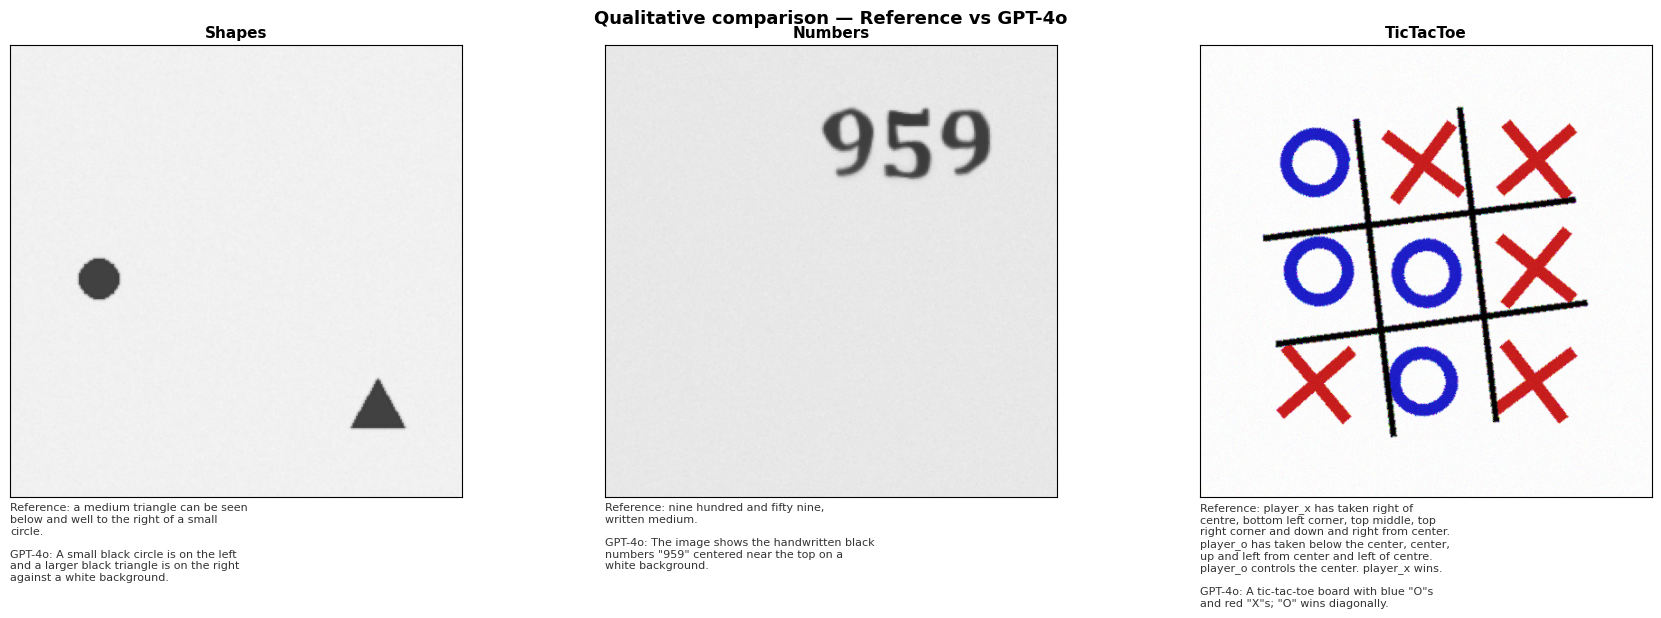

Plot saved → /content/drive/MyDrive/qualitative_gpt4o.png


In [33]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import textwrap
import pandas as pd
import os

GPT_SAVE_PATH = '/tmp/gpt4o_predictions.csv'
import matplotlib.pyplot as plt
import textwrap

gpt_df = pd.read_csv(GPT_SAVE_PATH)

samples = [
    gpt_df[gpt_df['dataset'] == ds].sample(1, random_state=42).iloc[0]
    for ds in ['Shapes_Data', 'Numbers_Data', 'TicTacToe_Data']
    if ds in gpt_df['dataset'].values
]

fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 6))
if len(samples) == 1:
    axes = [axes]
fig.suptitle('Qualitative comparison — Reference vs GPT-4o', fontsize=13, fontweight='bold')

for ax, sample in zip(axes, samples):
    img = PILImage.open(sample['file_path']).convert('RGB')
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(sample['dataset'].replace('_Data', ''), fontsize=11, fontweight='bold')
    ref_wrapped = textwrap.fill(f'Reference: {sample["reference"]}', 45)
    gpt_wrapped = textwrap.fill(f'GPT-4o: {sample["prediction"]}', 45)
    ax.set_xlabel(f'{ref_wrapped}\n\n{gpt_wrapped}', fontsize=8, loc='left', color='#333')

plt.tight_layout()
out_plot = os.path.join(MODEL_RESULTS, 'qualitative_gpt4o.png')
plt.savefig(out_plot, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {out_plot}')